In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Read dataset in below csv
df_new = pd.read_csv(r"E:\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv")

In [3]:
df_new.shape

(31325, 22)

In [4]:
df_new.columns

Index(['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
       'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
       'Is_Vegan_label', 'Is_Gluten_Free_label', 'Food_Name_label',
       'Meal_Type_breakfast', 'Meal_Type_dinner', 'Meal_Type_lunch',
       'Meal_Type_snack', 'Preparation_Method_baked',
       'Preparation_Method_fried', 'Preparation_Method_grilled',
       'Preparation_Method_raw'],
      dtype='object')

In [5]:
target_counts = df_new["Food_Name_label"].value_counts()
print(target_counts)

Food_Name_label
6    5914
2    4943
3    4464
5    3961
9    3451
4    2965
8    1984
0    1473
1    1185
7     985
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X = df_new.drop(columns=["Food_Name_label"])
y = df_new["Food_Name_label"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.tree import DecisionTreeClassifier


# Model
dt = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [8]:
y_pred2= dt.predict(X_test)
y_pred2

array([3, 3, 5, ..., 2, 3, 3], shape=(6265,))

In [9]:
y_pred1 = dt.predict(X_train)
y_pred1

array([2, 9, 2, ..., 0, 8, 5], shape=(25060,))

In [10]:
from sklearn.metrics import accuracy_score


train_acc = accuracy_score(y_train, y_pred1)
test_acc = accuracy_score(y_test, y_pred2)

print("Train accuracy after prediction :", train_acc)
print("Test accuracy after prediction:", test_acc)

Train accuracy after prediction : 0.9936951316839585
Test accuracy after prediction: 0.9870710295291301


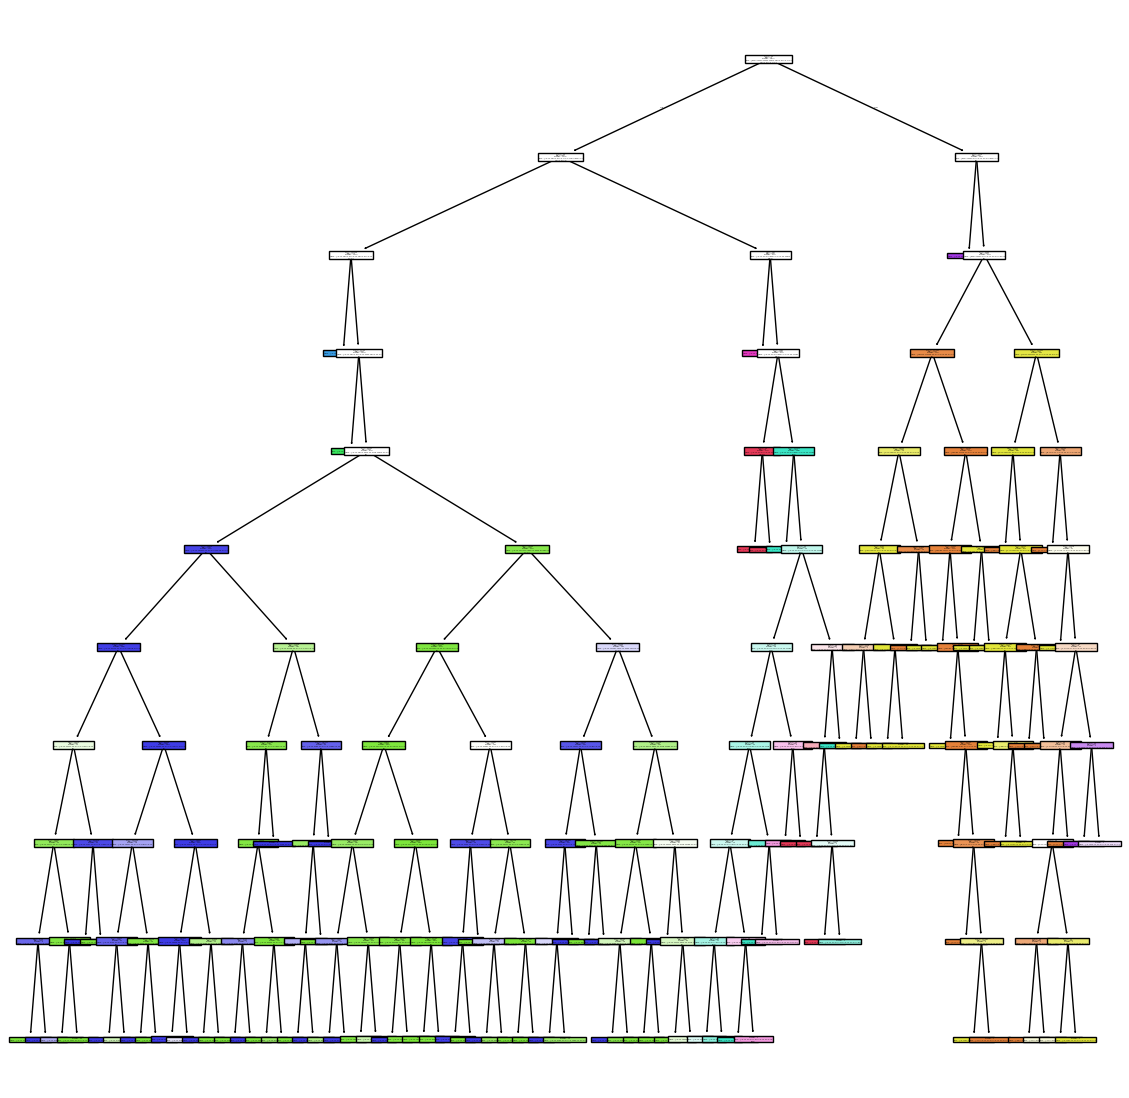

In [11]:
from sklearn.tree import plot_tree


plt.figure(figsize=(14,14))
plot_tree(dt,filled=True)
plt.show()

In [12]:
#max_depth
from sklearn.model_selection import cross_validate

clf = DecisionTreeClassifier(max_depth=5)

cv_results = cross_validate(clf,X_train,y_train,cv=5,scoring="accuracy",return_train_score=True)

print(cv_results["train_score"].mean())
print(cv_results["test_score"].mean())

0.9193834796488428
0.9166799680766161


In [13]:
depths = [3,4,5,6,7,9,10,11,13,15,18,20]

for i in depths:
  clf = DecisionTreeClassifier(max_depth=i)
  cv_results = cross_validate(clf,X_train,y_train,cv=5,scoring="accuracy",return_train_score=True)

  print(i,cv_results["train_score"].mean(),cv_results["test_score"].mean())

3 0.8000798084596967 0.7994812450119713
4 0.8684656823623303 0.8658419792498006
5 0.9193834796488428 0.9166799680766161
6 0.955696328810854 0.9509177972865123
7 0.9911911412609736 0.9864724660814046
9 0.9960893854748603 0.9884676775738228
10 0.9971268954509178 0.9889864325618516
11 0.9977354349561054 0.9885474860335195
13 0.9983240223463687 0.988707102952913
15 0.9984038308060654 0.988707102952913
18 0.9984138068635275 0.9882282521947326
20 0.9984138068635275 0.9885474860335195


In [14]:
# Max = 7

dt1 = DecisionTreeClassifier(max_depth=7)

In [15]:
dt1.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [16]:
y_pred2_dt1 = dt.predict(X_test)
y_pred2_dt1

array([3, 3, 5, ..., 2, 3, 3], shape=(6265,))

In [17]:
y_pred1_dt1 = dt.predict(X_train)
y_pred1_dt1

array([2, 9, 2, ..., 0, 8, 5], shape=(25060,))

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

train_acc = accuracy_score(y_train, y_pred1_dt1)
test_acc = accuracy_score(y_test, y_pred2_dt1)

print("Train accuracy after prediction :", train_acc)
print("Test accuracy after prediction:", test_acc)

Train accuracy after prediction : 0.9936951316839585
Test accuracy after prediction: 0.9870710295291301


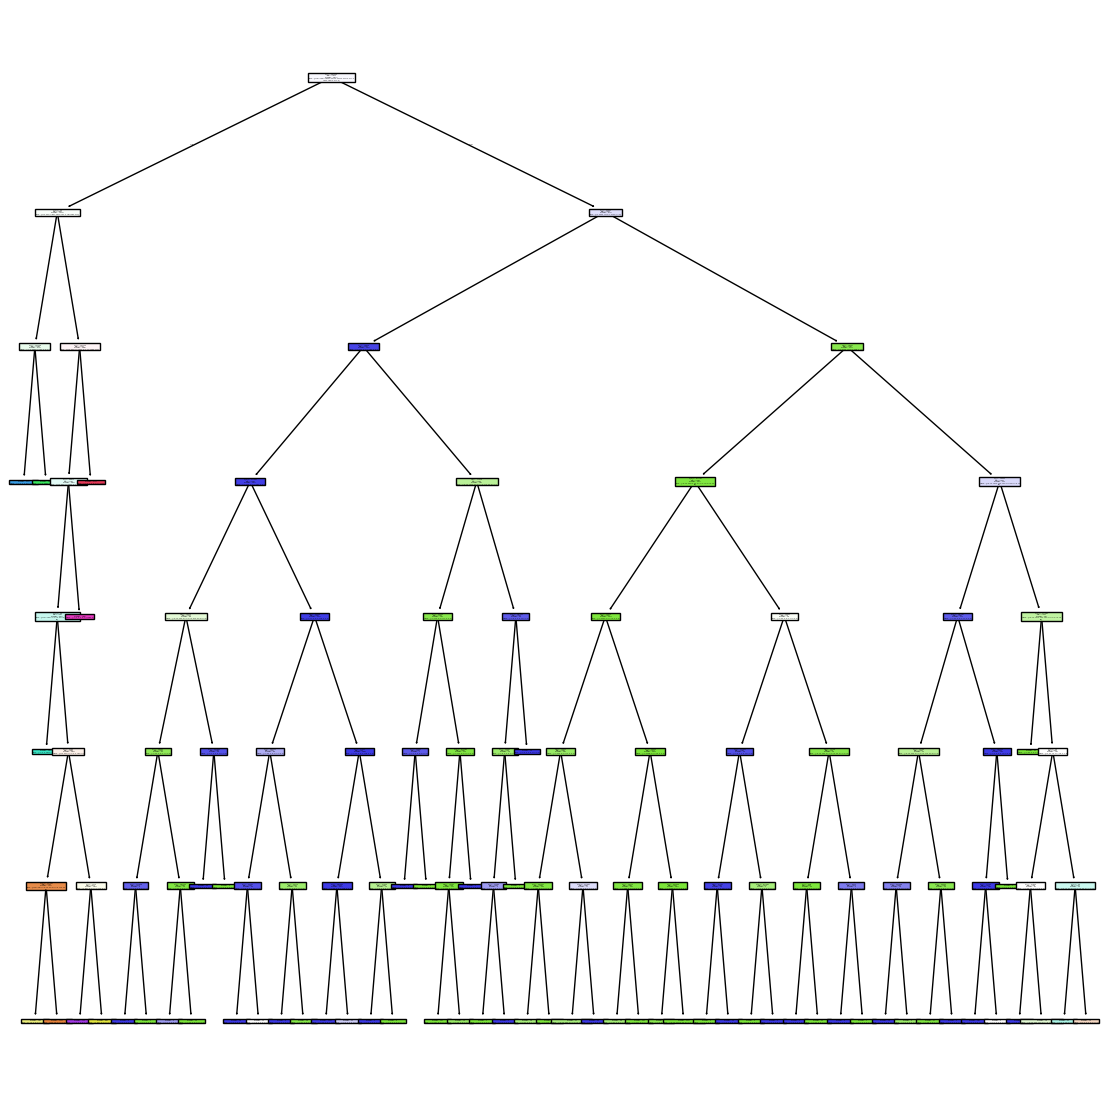

In [19]:
from sklearn.tree import plot_tree


plt.figure(figsize=(14,14))
plot_tree(dt1,filled=True)
plt.show()

Text(95.72222222222221, 0.5, 'Actual')

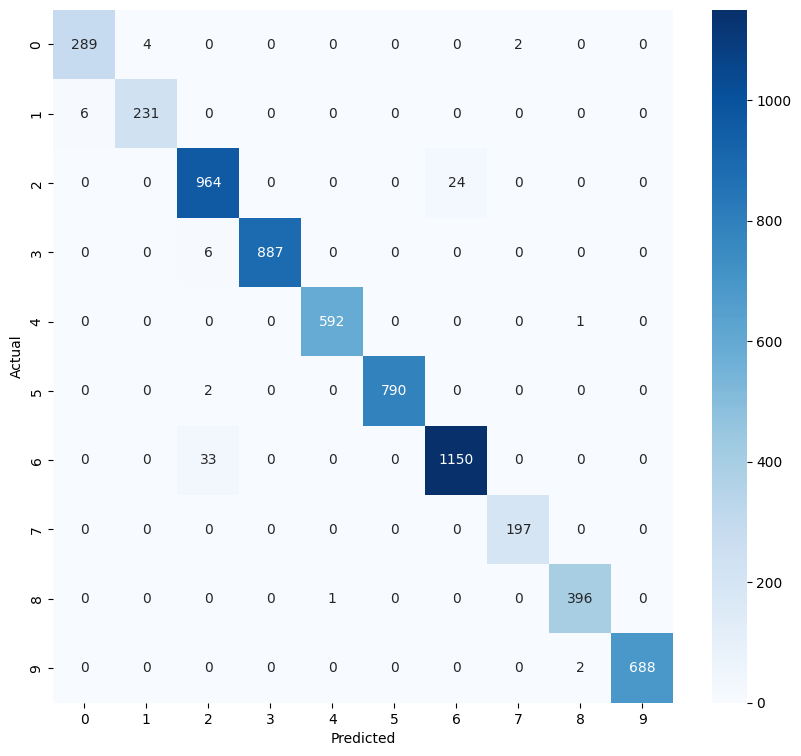

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred2_dt1)

plt.figure(figsize = (10, 9))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [21]:
from sklearn.metrics import classification_report

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred2_dt1))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       295
           1       0.98      0.97      0.98       237
           2       0.96      0.98      0.97       988
           3       1.00      0.99      1.00       893
           4       1.00      1.00      1.00       593
           5       1.00      1.00      1.00       792
           6       0.98      0.97      0.98      1183
           7       0.99      1.00      0.99       197
           8       0.99      1.00      0.99       397
           9       1.00      1.00      1.00       690

    accuracy                           0.99      6265
   macro avg       0.99      0.99      0.99      6265
weighted avg       0.99      0.99      0.99      6265



In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None]
}

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Depth:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Depth: {'max_depth': 10}
Best CV Accuracy: 0.9884277733439746


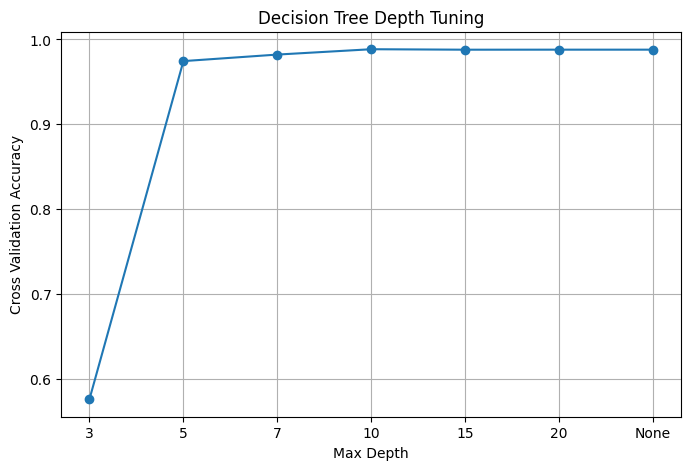

In [23]:
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(
    results['param_max_depth'].astype(str),
    results['mean_test_score'],
    marker='o'
)

plt.xlabel("Max Depth")
plt.ylabel("Cross Validation Accuracy")
plt.title("Decision Tree Depth Tuning")
plt.grid(True)
plt.show()